# Kubische Spline-Interpolation

Punkte $(x_i, y_i)$ können durch Polynome interpoliert werden. Wie wir bereits gesehen hatten, ist die Interpolation von "vielen", z.B. mehr als $4$ Punkten durch *ein* Polynom meist keine gute Idee: numerisch instabil und beliebiges Verhalten zwischen den Punkten.

Text(0.5, 1.0, 'Polynominterpolation')

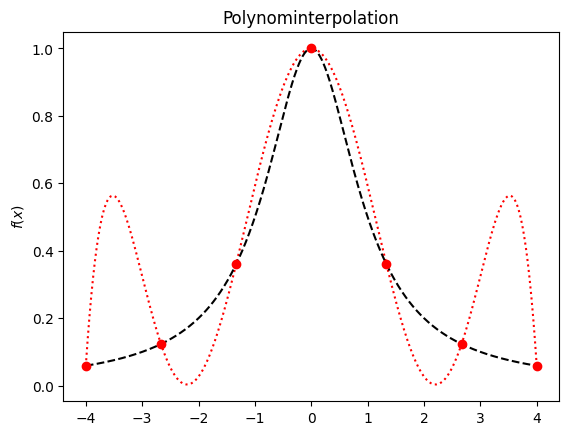

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator as ipo

N = 6
xi = np.linspace(-4,4, N+1)
f = lambda x: 1/(1 + x**2)
P = ipo(xi, f(xi))
plt.figure()
x = np.linspace(xi[0], xi[-1], 500)
plt.plot(x, P(x), 'r:', x, f(x), 'k--', xi, f(xi), 'or')
plt.ylabel("$f(x)$")
plt.title("Polynominterpolation")

Kubische, interpolierende Splines sind **stückweise Polynome**, jeweils vom Grad drei, so zusammengesetzt, dass die zusammengesetzte Funktion **zweimal** stetig differenzierbar ist. Für die Bahnkurve eines Roboters bedeutet dies, dass die Kraftverläufe noch stetig sind.

"\n# Polynominterpolation\nplt.figure()\nplt.plot(xx, f(xx), '--')\nplt.scatter(x, y)\nplt.plot(xx, np.polyval(p, xx))\n"

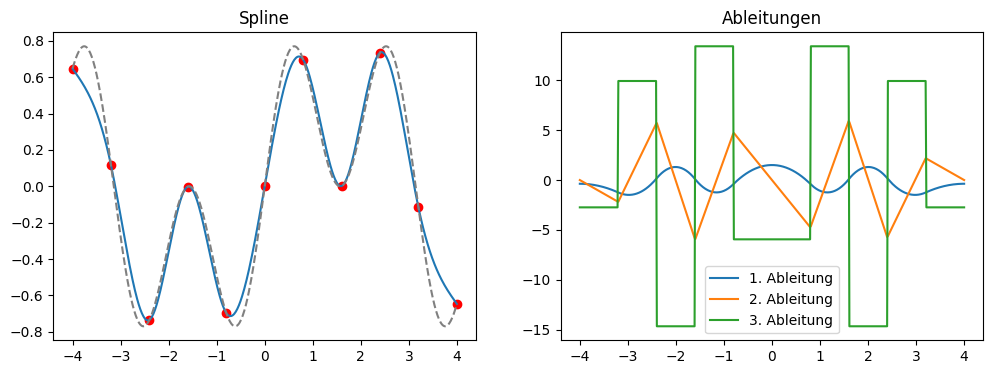

In [22]:
# -*- coding: utf-8 -*-
"""
Created on Mon May 15 12:26:34 2023

@author: chris
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# einfache Funktion
f = lambda x: np.cos(x) * np.sin(2*x)

# mit "Sprungstelle" 
# f = lambda x: 1 * (x < 0)

l, r = -4, 4            # x-Intervall
n = 10                   # Anzahl Punkte
x = np.linspace(l, r, n+1)
y = f(x)
h = (r-l) / n

#%% Momente berechnen

def momente(y):
    n = len(y) - 1
    d = np.ones(n - 1)
    ab = np.array([d, 4 * d, d])
    b = 6 / h**2 * (y[:-2] - 2 * y[1:-1] + y[2:])
    m = np.pad(solve_banded((1,1), ab, b), (1,1))
    return m

m = momente(y)
    
#%% Splinefunktion auswerten
def splineval(m, x, y, xx, der = 0):
    yy = np.zeros_like(xx)
    for j in range(len(x)-1):
        I = (xx >= x[j]) * (xx <= x[j+1])
        dp, dm = x[j+1] - xx[I], xx[I] - x[j]
        if der == 0: # Splinefunktion
            yy[I]  = ( dp**3 * m[j] + dm**3 * m[j+1] ) / (6 * h)
            yy[I] += ( dp    * y[j] + dm    * y[j+1] ) / h 
            yy[I] -= ( dp    * m[j] + dm    * m[j+1] ) * h / 6
        elif der == 1: # erste Ableitung
            yy[I]  = ( -3 * dp**2 * m[j] + 3 * dm**2 * m[j+1] ) / (6 * h)
            yy[I] += ( - y[j] + y[j+1] ) / h 
            yy[I] -= ( - m[j] + m[j+1] ) * h / 6            
        elif der == 2: # zweite Ableitung
            yy[I]  = ( dp * m[j] + dm * m[j+1] ) / h
        elif der == 3: # dritte Ableitung
            yy[I]  = ( - m[j] + m[j+1] ) / h            
    return yy


# %% Polynominterpolation
p = np.polyfit(x, y, deg = len(x) - 1)
# %% Interpolation einer Funktion
xx   = np.linspace(l, r, 500)

plt.close("all")

fig, ax = plt.subplots(1,2, figsize=(12, 4) )

ax[0].scatter(x, y, color = 'r')
ax[0].plot(xx, splineval(m, x, y, xx, der = 0))
ax[0].plot(xx, f(xx), color = "gray", linestyle = "--")
ax[0].set_title("Spline")

ax[1].plot(xx, splineval(m, x, y, xx, der = 1), label = "1. Ableitung")
ax[1].plot(xx, splineval(m, x, y, xx, der = 2), label = "2. Ableitung")
ax[1].plot(xx, splineval(m, x, y, xx, der = 3), label = "3. Ableitung")
ax[1].legend()
ax[1].set_title("Ableitungen")

"""
# Polynominterpolation
plt.figure()
plt.plot(xx, f(xx), '--')
plt.scatter(x, y)
plt.plot(xx, np.polyval(p, xx))
"""


Punkte in $\mathbb{R}^n$ können interpoliert werden, indem die Komponenten einzeln gegen eine $t$-Achse interpoliert werden. 

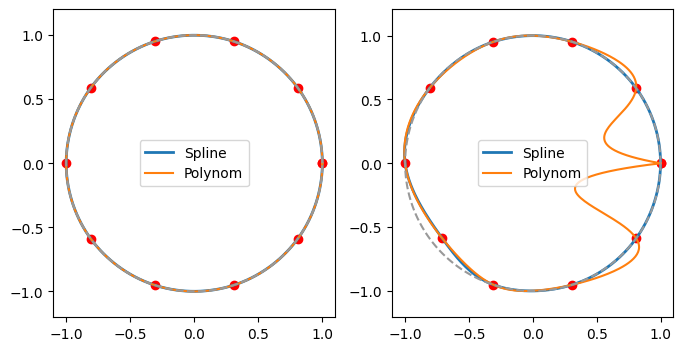

In [23]:
#%% einfache Funktion
f1 = np.cos
f2 = np.sin 

l, r = 0, 2*np.pi            # x-Intervall
N = 10                   # N+1 = Anzahl Punkte
ti = np.linspace(l, r, N+1)
xi, yi = f1(ti), f2(ti)
h = (r-l) / N

#%% Momente berechnen

def momentePer(y):
    N = len(y) - 1
    d = np.ones(N)
    A = np.diag(4 * d) + np.diag(d[1:], -1) + np.diag(d[:-1], 1) 
    A[0, -1] = 1
    A[-1, 0] = 1
    b = y[2:] - 2 * y[1:-1] + y[:-2]
    b = np.append(b, y[1] - y[-1] - y[0] + y[-2])
    b *= 6 / h**2
    m = np.zeros(N+1)
    m[1:] = np.linalg.solve(A, b)
    m[0] = m[-1]
    return m

def momente(y):
    N = len(y) - 1
    d = np.ones(N - 1) 
    ab = np.array([d, 4 * d, d])
    b = 6 / h**2 * (y[:-2] - 2 * y[1:-1] + y[2:])
    m = np.pad(solve_banded((1,1), ab, b), (1,1))
    return m

#%% Splinefunktion auswerten
def splineval(m, x, y, xx, der = 0):
    yy = np.zeros_like(xx)
    for j in range(len(x)-1):
        I = (xx >= x[j]) * (xx <= x[j+1])
        dp, dm = x[j+1] - xx[I], xx[I] - x[j]
        if der == 0: # Splinefunktion
            yy[I]  = ( dp**3 * m[j] + dm**3 * m[j+1] ) / (6 * h)
            yy[I] += ( dp    * y[j] + dm    * y[j+1] ) / h 
            yy[I] -= ( dp    * m[j] + dm    * m[j+1] ) * h / 6
        elif der == 1: # erste Ableitung
            yy[I]  = ( -3 * dp**2 * m[j] + 3 * dm**2 * m[j+1] ) / (6 * h)
            yy[I] += ( - y[j] + y[j+1] ) / h 
            yy[I] -= ( - m[j] + m[j+1] ) * h / 6            
        elif der == 2: # zweite Ableitung
            yy[I]  = ( dp * m[j] + dm * m[j+1] ) / h
        elif der == 3: # dritte Ableitung
            yy[I]  = ( - m[j] + m[j+1] ) / h            
    return yy

t   = np.linspace(l, r, 500)

"""
plt.figure()
mx, my = momentePer(xi), momentePer(yi)
plt.plot(t, splineval(mx, ti, xi, t, der = 0))
plt.plot(t, splineval(my, ti, yi, t, der = 0))
plt.scatter(ti, f1(ti), color = 'r')
"""

fig, ax = plt.subplots(1, 2, figsize = (8, 4))

for k in range(2):
    
    ax[k].scatter(xi, yi, color = 'r')
     # Spline Interpolation
    mx, my = momentePer(xi), momentePer(yi)
    ax[k].plot(splineval(mx, ti, xi, t, der = 0), splineval(my, ti, yi, t, der = 0), linewidth = 2, label = "Spline")
    
    # Polynominterpolation
    px = np.polyfit(ti, xi, deg = len(ti) - 1)
    py = np.polyfit(ti, yi, deg = len(ti) - 1)
    
    ax[k].plot(np.polyval(px, t), np.polyval(py, t), label = "Polynom")
    
    ax[k].plot(f1(t), f2(t), color = [.6,.6,.6], linestyle = "--")
    ax[k].axis("equal")
    ax[k].legend()
    
    xi[6] += .1    # einen Punkt etwas verschieben






Kubische Splines **interpolieren** die Punkte. Wenn die Punkte starke Schwankungen aufweisen, kann der Spline in der Nähe einer solchen "Sprungstelle" oszillieren. Es gibt andere Spline-Typen, z.B. **B-Splines**, die je nach Anwendung besser geeignet sind. Das Beispiel unten ist ein **aproximierender** B-Spline, d.h. es werden nicht alle Punkte interpoliert. Man kann erzwingen, dass Punkte interpoliert werden, was dann wieder auf Kosten der Differenzierbarkeit geht -- jeder Spline hat seine Vor- und Nachteile.

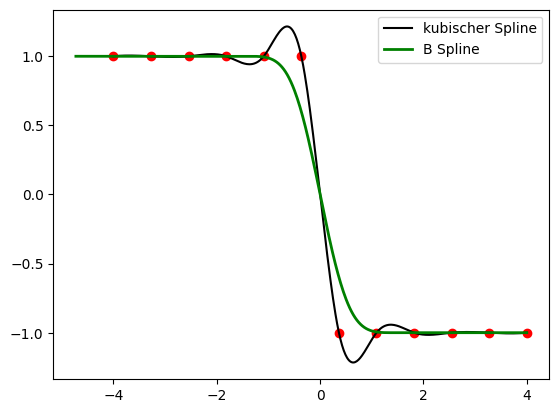

In [24]:
from scipy.interpolate import CubicSpline as cSp
from scipy.interpolate import BSpline as bSp

# %%
N = 12

f = lambda x: 1 * (x < 0) - 1*(x > 0)
xi = np.linspace(-4,4, N)
yi = f(xi)

S = cSp(xi, yi)

k = 2+2
ti = np.linspace(0,1, N+k)
splX = bSp(ti, xi, k)
splY = bSp(ti, yi, k)

plt.figure()
x = np.linspace(xi[0], xi[-1], 500)
t = np.linspace(ti[0]+.1, ti[-1]-.1, 500)
plt.plot(x, S(x), 'k-', label = "kubischer Spline")
plt.scatter(xi, yi, color = "r")
plt.plot(splX(t), splY(t), 'g-', linewidth = 2, label = "B Spline")
plt.legend()
